In [1]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Create imbalanced dataset
X, y = make_classification(
    n_samples=5000,
    n_features=20,
    n_informative=15,
    weights=[0.95, 0.05],
    random_state=42
)

print(f"Class distribution: {pd.Series(y).value_counts().to_dict()}")

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train vanilla model - no adjustments
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("\nNo class weight adjustment:")
print(classification_report(y_test, y_pred))

Class distribution: {0: 4736, 1: 264}

No class weight adjustment:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       955
           1       0.79      0.24      0.37        45

    accuracy                           0.96      1000
   macro avg       0.88      0.62      0.68      1000
weighted avg       0.96      0.96      0.95      1000



In [2]:
# Train with class weight adjustment
model_weighted = LogisticRegression(max_iter=1000, class_weight='balanced')
model_weighted.fit(X_train, y_train)
y_pred_weighted = model_weighted.predict(X_test)

print("With class weight adjustment:")
print(classification_report(y_test, y_pred_weighted))

With class weight adjustment:
              precision    recall  f1-score   support

           0       0.99      0.82      0.90       955
           1       0.17      0.80      0.28        45

    accuracy                           0.82      1000
   macro avg       0.58      0.81      0.59      1000
weighted avg       0.95      0.82      0.87      1000



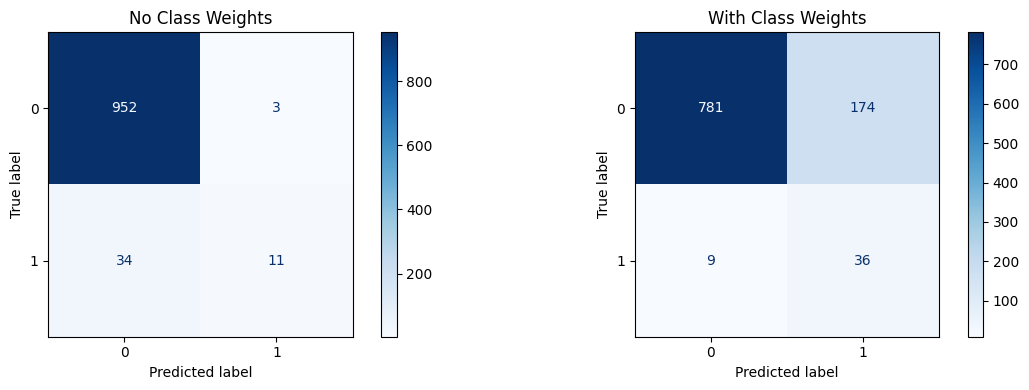

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('No Class Weights')

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_weighted)).plot(ax=axes[1], cmap='Blues')
axes[1].set_title('With Class Weights')

plt.tight_layout()
plt.show()